# TALLER PREPROCESAMIENTO DE DATOS
## Estadísticas de Jugadores de Fútbol — Top 5 Ligas Europeas (2022–2026)

---

**Integrantes del equipo:** *(completar)*  
**Fecha de entrega:** 4 de marzo de 2025  
**Asignatura:** Minería de Datos  

---

## Resumen Ejecutivo

Este proyecto aborda el preprocesamiento integral de cuatro fuentes de datos relacionadas con estadísticas individuales de jugadores de fútbol en las cinco principales ligas europeas (Premier League, La Liga, Serie A, Bundesliga y Ligue 1), abarcando las temporadas 2022-23, 2023-24, 2024-25 y 2025-26. El conjunto de datos consolidado supera los **11,000 registros** y más de **100 variables** por fuente. Se realizó exploración inicial, caracterización estructural, preprocesamiento (valores faltantes, inconsistencias de formato, estandarización) y análisis descriptivo. El resultado es un dataset limpio, integrado y listo para aplicar técnicas de aprendizaje supervisado (predicción de goles, clasificación de rendimiento) o no supervisado (clustering de perfiles de jugadores).

---
## 1. Introducción

El análisis de datos deportivos ha crecido enormemente en la última década gracias a la disponibilidad de estadísticas detalladas por jugador. En el fútbol europeo, sitios como **FBref (Sports Reference)** ofrecen datos granulares sobre rendimiento ofensivo, defensivo, creación de jugadas, portería, entre otros. Sin embargo, estos datos provienen de distintas temporadas y con esquemas de columnas variables, lo que requiere un preprocesamiento riguroso antes de cualquier análisis.

**Preguntas de investigación que pueden responderse con estos datos:**
1. ¿Es posible predecir los goles de un jugador a partir de sus estadísticas de disparo (xG, SoT, Sh)?
2. ¿Qué perfiles de jugadores existen en las grandes ligas según sus características técnicas y físicas?
3. ¿Cómo ha evolucionado el rendimiento promedio de los jugadores entre la temporada 2022-23 y 2025-26?
4. ¿Cuál liga tiene mayor proporción de jugadores ofensivos de alto rendimiento?

**Dominio:** Estadísticas individuales de jugadores de fútbol profesional.  
**Fuentes:** Datos recolectados de FBref / Kaggle (Sports Reference), cubriendo las temporadas 2022-2026.

---
## 2. Configuración del Entorno — Importación de Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Librerías importadas correctamente')

---
## 3. Descripción del Dominio y Fuentes de Datos

| # | Archivo | Temporada | Registros | Variables | Fuente |
|---|---------|-----------|-----------|-----------|--------|
| 1 | `2022-2023_Football_Player_Stats_normalized.csv` | 2022-23 | 2,689 | 124 | FBref/Kaggle |
| 2 | `players_data-2024_2025.csv` | 2024-25 | 2,854 | 267 | FBref |
| 3 | `players_data-2025_2026.csv` | 2025-26 | 2,625 | 102 | FBref |
| 4 | `top5-players.csv` | 2023-24 | 2,852 | 37 | FBref |

**Total registros:** 11,020  
**Ligas cubiertas:** Premier League (ENG), La Liga (ESP), Serie A (ITA), Bundesliga (GER), Ligue 1 (FRA)  
**Tipo de datos:** Transaccionales (un registro por jugador por temporada)  
**Granularidad:** Individual (nivel de jugador)  
**Propietario de los datos:** Sports Reference LLC (FBref.com) — licencia de uso no comercial

### ¿Por qué este dominio?
El fútbol es el deporte más popular del mundo. Los datos de rendimiento individual son usados por scouts, analistas y clubes para tomar decisiones sobre fichajes y tácticas. El dominio es rico en variables numéricas continuas, categorías bien definidas y una semántica comprensible, lo que lo convierte en un excelente candidato para técnicas de ML.

---
## 4. Paso 2 — Exploración Inicial y Contextualización

In [ ]:
# ────────────────────────────────────────────────
# Carga de los cuatro datasets
# ────────────────────────────────────────────────
df_2223 = pd.read_csv('players_data_2022-2023.csv')
df_2425 = pd.read_csv('players_data-2024_2025.csv')
df_2526 = pd.read_csv('players_data-2025_2026.csv')
df_top5 = pd.read_csv('players_data-2025_2026.csv')

# Etiqueta de temporada para trazabilidad
df_2223['Temporada'] = '2022-23'
df_2425['Temporada'] = '2024-25'
df_2526['Temporada'] = '2025-26'
df_top5['Temporada'] = '2023-24'

datasets = {
    '2022-23': df_2223,
    '2023-24': df_top5,
    '2024-25': df_2425,
    '2025-26': df_2526
}

print('📦 Datasets cargados:')
for nombre, df in datasets.items():
    print(f'  Temporada {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas')

print(f'\n📊 Total de registros: {sum(d.shape[0] for d in datasets.values()):,}')

📦 Datasets cargados:
  Temporada 2022-23: 2689 filas x 125 columnas
  Temporada 2023-24: 2625 filas x 103 columnas
  Temporada 2024-25: 2854 filas x 268 columnas
  Temporada 2025-26: 2625 filas x 103 columnas

📊 Total de registros: 10,793


In [ ]:
# ────────────────────────────────────────────────
# Exploración de cada dataset: primeras filas
# ────────────────────────────────────────────────
print('=== Dataset 2022-23 ===')
display(df_2223.head(3))

print('\n=== Dataset 2023-24 (top5) ===')
display(df_top5.head(3))

print('\n=== Dataset 2024-25 ===')
display(df_2425[df_2425.columns[:20]].head(3))  # solo primeras 20 cols para visualizar

print('\n=== Dataset 2025-26 ===')
display(df_2526.head(3))

=== Dataset 2022-23 ===


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%,Temporada
0,1,Brenden Aaronson,USA,MFFW,Leeds United,Premier League,22,2000,20,19,...,2.54,0.51,0.0,0.0,0.0,4.86,0.34,1.19,22.2,2022-23
1,2,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,35,1987,22,22,...,0.18,1.59,0.0,0.0,0.0,6.64,2.18,1.23,64.0,2022-23
2,3,Himad Abdelli,FRA,MFFW,Angers,Ligue 1,23,1999,14,8,...,1.05,1.40,0.0,0.0,0.0,8.14,0.93,1.05,47.1,2022-23



=== Dataset 2023-24 (top5) ===


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG,Temporada
0,1,Brenden Aaronson,us USA,"FW,MF",Leeds United,eng Premier League,25.0,2000.0,25,19,...,0,0,14,35,5,28,12,21,0,2023-24
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,2,1,...,0,0,2,1,0,3,2,2,0,2023-24
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,14,3,...,0,0,3,3,1,24,1,0,0,2023-24



=== Dataset 2024-25 ===


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,86,1.0,0,0,0,0,0,0,0,0
1,2,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,2000.0,4,1,120,1.3,0,0,0,0,0,0,2,0
2,3,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,2003.0,1,1,65,0.7,0,0,0,0,0,0,1,0



=== Dataset 2025-26 ===


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG,Temporada
0,1,Brenden Aaronson,us USA,"FW,MF",Leeds United,eng Premier League,25.0,2000.0,25,19,...,0,0,14,35,5,28,12,21,0,2025-26
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,2,1,...,0,0,2,1,0,3,2,2,0,2025-26
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,14,3,...,0,0,3,3,1,24,1,0,0,2025-26


In [ ]:
# ────────────────────────────────────────────────
# Tipos de datos por dataset
# ────────────────────────────────────────────────
for nombre, df in datasets.items():
    n_num = df.select_dtypes(include='number').shape[1]
    n_cat = df.select_dtypes(include='object').shape[1]
    print(f'Temporada {nombre}: {n_num} vars numéricas | {n_cat} vars categóricas')

Temporada 2022-23: 119 vars numéricas | 6 vars categóricas
Temporada 2023-24: 81 vars numéricas | 22 vars categóricas
Temporada 2024-25: 232 vars numéricas | 36 vars categóricas
Temporada 2025-26: 81 vars numéricas | 22 vars categóricas


In [ ]:
# ────────────────────────────────────────────────
# Columnas comunes entre todos los datasets
# ────────────────────────────────────────────────
cols_comunes = set(df_2223.columns)
for df in [df_top5, df_2425, df_2526]:
    cols_comunes &= set(df.columns)

print(f'✅ Columnas comunes a los 4 datasets ({len(cols_comunes)}):')
print(sorted(cols_comunes))

✅ Columnas comunes a los 4 datasets (28):
['2CrdY', '90s', 'Age', 'Born', 'Comp', 'CrdR', 'CrdY', 'Crs', 'Fld', 'Fls', 'G/Sh', 'G/SoT', 'Int', 'MP', 'Min', 'Nation', 'OG', 'Off', 'PKatt', 'Player', 'Pos', 'Rk', 'SoT', 'SoT%', 'Squad', 'Starts', 'Temporada', 'TklW']


In [ ]:
# ────────────────────────────────────────────────
# Información general de cada dataset (dtypes, nulls)
# ────────────────────────────────────────────────
for nombre, df in datasets.items():
    print(f'\n=== {nombre} info ===')
    print(df.info(verbose=False, show_counts=True))


=== 2022-23 info ===
<class 'pandas.DataFrame'>
RangeIndex: 2689 entries, 0 to 2688
Columns: 125 entries, Rk to Temporada
dtypes: float64(112), int64(7), str(6)
memory usage: 2.6 MB
None

=== 2023-24 info ===
<class 'pandas.DataFrame'>
RangeIndex: 2625 entries, 0 to 2624
Columns: 103 entries, Rk to Temporada
dtypes: float64(41), int64(40), str(22)
memory usage: 2.1 MB
None

=== 2024-25 info ===
<class 'pandas.DataFrame'>
RangeIndex: 2854 entries, 0 to 2853
Columns: 268 entries, Rk to Temporada
dtypes: float64(111), int64(121), str(36)
memory usage: 5.8 MB
None

=== 2025-26 info ===
<class 'pandas.DataFrame'>
RangeIndex: 2625 entries, 0 to 2624
Columns: 103 entries, Rk to Temporada
dtypes: float64(41), int64(40), str(22)
memory usage: 2.1 MB
None


### Observaciones de la Exploración Inicial

- **Tipo de datos:** Todos los datasets son de tipo transaccional con granularidad individual (un registro = un jugador en una temporada). No son series de tiempo puras, aunque sí hay registro temporal entre temporadas.
- **Periodo temporal cubierto:** Temporadas 2022-23 a 2025-26 (cuatro años).
- **Metadatos:** Los datos provienen de FBref, que documenta cada estadística en su sitio web. No hay un diccionario de datos formal adjunto, pero las abreviaturas son estándar del fútbol.
- **Inconsistencias detectadas en exploración inicial:**
  - La columna `Nation` tiene formatos distintos: `'USA'` en 2022-23 vs `'us USA'` en los demás.
  - La columna `Comp` tiene formatos distintos: `'Premier League'` en 2022-23 vs `'eng Premier League'` en los demás.
  - La columna `Age` es `int` en 2022-23 y `float` en el resto.
  - El dataset 2024-25 tiene 267 columnas por incluir estadísticas de portero duplicadas; la mayoría corresponden solo a porteros (>92% nulos para no-porteros).
  - Los datasets tienen diferente número de columnas, por lo que la integración debe hacerse sobre el subconjunto de columnas comunes o por unión controlada.

---
## 5. Paso 3 — Caracterización Estructural y Diseño de Almacenamiento

### 5.1 Descripción de Variables Clave

| Variable | Tipo | Descripción | Escala |
|----------|------|-------------|--------|
| `Player` | Categórico / Texto | Nombre del jugador | Nominal |
| `Nation` | Categórico | Nacionalidad (código ISO) | Nominal |
| `Pos` | Categórico | Posición táctica (GK, DF, MF, FW, combinaciones) | Nominal |
| `Squad` | Categórico | Club del jugador | Nominal |
| `Comp` | Categórico | Liga/Competición | Nominal |
| `Age` | Numérico entero | Edad del jugador | Razón |
| `Born` | Numérico entero | Año de nacimiento | Intervalo |
| `MP` | Numérico entero | Partidos jugados | Razón |
| `Starts` | Numérico entero | Partidos como titular | Razón |
| `Min` | Numérico entero | Minutos jugados | Razón |
| `90s` | Numérico decimal | Equivalente a 90 minutos jugados | Razón |
| `Gls` / `Goals` | Numérico entero | Goles anotados | Razón |
| `Ast` | Numérico entero | Asistencias | Razón |
| `G+A` | Numérico entero | Goles + Asistencias | Razón |
| `xG` | Numérico decimal | Expected Goals (calidad de disparos) | Razón |
| `xAG` | Numérico decimal | Expected Assisted Goals | Razón |
| `PrgC` | Numérico entero | Conducciones progresivas | Razón |
| `PrgP` | Numérico entero | Pases progresivos | Razón |
| `CrdY` | Numérico entero | Tarjetas amarillas | Razón |
| `CrdR` | Numérico entero | Tarjetas rojas | Razón |
| `SoT` | Numérico decimal | Disparos a puerta | Razón |
| `SoT%` | Numérico decimal | Porcentaje de disparos a puerta | Razón |
| `Temporada` | Categórico | Temporada de origen del registro | Nominal |

> Las variables de portero (GA, Saves, Save%, CS, etc.) aplican solo a registros con `Pos == 'GK'`.

### 5.2 Propuesta de Esquema de Almacenamiento — Data Warehouse

Se propone un **esquema estrella (Star Schema)** con las siguientes tablas:

```
              ┌──────────────────┐
              │  dim_jugador     │
              │  ─────────────── │
              │  id_jugador (PK) │
              │  nombre          │
              │  nacion          │
              │  año_nacimiento  │
              └────────┬─────────┘
                       │
┌──────────────┐  ┌────┴───────────────────────┐  ┌──────────────┐
│  dim_club    │  │     fact_estadisticas      │  │ dim_liga     │
│ ──────────── │  │ ─────────────────────────  │  │ ──────────── │
│ id_club (PK) ├──┤ id_jugador (FK)            ├──┤ id_liga (PK) │
│ nombre_club  │  │ id_club (FK)               │  │ nombre       │
│ ciudad       │  │ id_liga (FK)               │  │ pais         │
│ pais         │  │ id_temporada (FK)          │  └──────────────┘
└──────────────┘  │ pos, MP, Starts, Min, 90s  │
                  │ Gls, Ast, xG, xAG, PrgC    │   ┌──────────────────┐
                  │ PrgP, CrdY, CrdR, SoT...   ├───┤ dim_temporada    │
                  └────────────────────────────┘   │ ──────────────── │
                                                   │ id_temporada (PK)│
                                                   │ temporada_label  │
                                                   │ año_inicio       │
                                                   │ año_fin          │
                                                   └──────────────────┘
```

**Justificación:** El esquema estrella permite consultas analíticas eficientes (OLAP). La tabla de hechos centraliza todas las métricas numéricas por jugador-temporada, mientras las dimensiones permiten filtrar por liga, club, temporada o jugador individualmente. Esto facilita agregaciones como "goles promedio por liga y temporada" en tiempo O(1) sobre índices.

---
## 6. Paso 4 — Preprocesamiento y Limpieza de Datos

In [ ]:
# ============================================================
# PASO 4.1: ESTANDARIZACIÓN DE COLUMNA 'Nation'
# Problema: '2022-23' tiene formato 'USA', los demás 'us USA'
# Solución: extraer solo el código de 3 letras mayúsculas
# ============================================================

def normalizar_nation(valor):
    """Extrae el código de 3 letras de la columna Nation.
    Ejemplos: 'us USA' -> 'USA' | 'USA' -> 'USA' | 'fr FRA' -> 'FRA'
    """
    if pd.isna(valor):
        return np.nan
    partes = str(valor).strip().split()
    # El código de 3 letras en mayúsculas es el que nos interesa
    for p in partes:
        if len(p) == 3 and p.isupper():
            return p
    return str(valor).strip()  # fallback

for nombre, df in datasets.items():
    antes = df['Nation'].dropna().head(3).tolist()
    df['Nation'] = df['Nation'].apply(normalizar_nation)
    despues = df['Nation'].dropna().head(3).tolist()
    print(f'{nombre}: {antes} → {despues}')

print('\n✅ Columna Nation normalizada')

2022-23: ['USA', 'MAR', 'FRA'] → ['USA', 'MAR', 'FRA']
2023-24: ['us USA', 'eng ENG', 'ma MAR'] → ['USA', 'ENG', 'MAR']
2024-25: ['eng ENG', 'eng ENG', 'es ESP'] → ['ENG', 'ENG', 'ESP']
2025-26: ['us USA', 'eng ENG', 'ma MAR'] → ['USA', 'ENG', 'MAR']

✅ Columna Nation normalizada


In [ ]:
# ============================================================
# PASO 4.2: ESTANDARIZACIÓN DE COLUMNA 'Comp'
# Problema: 'Premier League' vs 'eng Premier League'
# Solución: mapeo a nombre canónico
# ============================================================

mapa_ligas = {
    'Premier League':     'Premier League',
    'eng Premier League': 'Premier League',
    'La Liga':            'La Liga',
    'es La Liga':         'La Liga',
    'Serie A':            'Serie A',
    'it Serie A':         'Serie A',
    'Bundesliga':         'Bundesliga',
    'de Bundesliga':      'Bundesliga',
    'Ligue 1':            'Ligue 1',
    'fr Ligue 1':         'Ligue 1',
}

for nombre, df in datasets.items():
    df['Comp'] = df['Comp'].map(mapa_ligas).fillna(df['Comp'])

print('Valores únicos en Comp después de normalización:')
print(df_2223['Comp'].unique())
print('\n✅ Columna Comp normalizada')

Valores únicos en Comp después de normalización:
<StringArray>
['Premier League', 'Ligue 1', 'Serie A', 'La Liga', 'Bundesliga']
Length: 5, dtype: str

✅ Columna Comp normalizada


In [ ]:
# ============================================================
# PASO 4.3: ESTANDARIZACIÓN DE COLUMNA 'Age'
# Problema: int en 2022-23, float en los demás (ej. 24.0)
#           En 2024-25 puede aparecer como '24-112' (días)
# Solución: extraer la parte entera, convertir a int
# ============================================================

def normalizar_edad(valor):
    """Extrae el año entero de la edad. Acepta: 24, 24.0, '24-112', '24'"""
    if pd.isna(valor):
        return np.nan
    s = str(valor).split('-')[0].split('.')[0]
    try:
        return int(s)
    except ValueError:
        return np.nan

for nombre, df in datasets.items():
    df['Age'] = df['Age'].apply(normalizar_edad)

print('Age dtype y rango después de normalización:')
for nombre, df in datasets.items():
    print(f'  {nombre}: dtype={df["Age"].dtype} | min={df["Age"].min()} | max={df["Age"].max()} | nulls={df["Age"].isna().sum()}')

print('\n✅ Columna Age normalizada')

Age dtype y rango después de normalización:
  2022-23: dtype=int64 | min=15 | max=41 | nulls=0
  2023-24: dtype=float64 | min=16.0 | max=42.0 | nulls=2
  2024-25: dtype=float64 | min=15.0 | max=41.0 | nulls=8
  2025-26: dtype=float64 | min=16.0 | max=42.0 | nulls=2

✅ Columna Age normalizada


In [ ]:
# ============================================================
# PASO 4.4: ANÁLISIS Y TRATAMIENTO DE VALORES FALTANTES
# ============================================================

print('=== VALORES FALTANTES POR DATASET (columnas con > 5% nulos) ===')

for nombre, df in datasets.items():
    nulls_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    alta_nulidad = nulls_pct[nulls_pct > 5]
    print(f'\n{nombre}: {len(alta_nulidad)} columnas con > 5% nulos')
    if len(alta_nulidad) > 0 and len(alta_nulidad) <= 15:
        print(alta_nulidad.to_string())
    elif len(alta_nulidad) > 15:
        print(f'  (Primeras 5): {alta_nulidad.head(5).to_string()}')
        print(f'  ... y {len(alta_nulidad)-5} columnas más')

=== VALORES FALTANTES POR DATASET (columnas con > 5% nulos) ===

2022-23: 0 columnas con > 5% nulos

2023-24: 29 columnas con > 5% nulos
  (Primeras 5): CS%                94.019048
Save%              93.980952
SoTA               93.942857
Rk_stats_keeper    93.942857
W                  93.942857
  ... y 24 columnas más

2024-25: 64 columnas con > 5% nulos
  (Primeras 5): CS%                      92.887176
PSxG/SoT                 92.782060
Save%                    92.782060
AvgDist                  92.711983
Cmp%_stats_keeper_adv    92.641906
  ... y 59 columnas más

2025-26: 29 columnas con > 5% nulos
  (Primeras 5): CS%                94.019048
Save%              93.980952
SoTA               93.942857
Rk_stats_keeper    93.942857
W                  93.942857
  ... y 24 columnas más


In [ ]:
# ============================================================
# ESTRATEGIA DE MANEJO DE NULOS:
# 1. Columnas de portero (GA, Saves, Save%, etc.) → nulos esperados
#    para no-porteros. Se mantienen como NaN (son estructurales).
# 2. Columnas numéricas de rendimiento con < 20% nulos → imputar con 0
#    (un jugador sin dato en esa estadística probablemente no participó)
# 3. Columnas categóricas con nulos → no imputar, mantener NaN
# ============================================================

# Columnas de portero que deben estar vacías para jugadores de campo
cols_portero = ['GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%',
                'PKA', 'PKsv', 'PKm', 'PSxG', 'PSxG/SoT', 'AvgLen', 'AvgDist', 'Stp%']

# Para el dataset top5 (más completo y que será base de análisis):
# Imputar columnas numéricas de rendimiento con 0 cuando el jugador participó
cols_num_top5 = df_top5.select_dtypes(include='number').columns.tolist()
cols_a_imputar = [c for c in cols_num_top5 if c not in cols_portero and c != 'Rk']

nulos_antes = df_top5[cols_a_imputar].isnull().sum().sum()
df_top5[cols_a_imputar] = df_top5[cols_a_imputar].fillna(0)
nulos_despues = df_top5[cols_a_imputar].isnull().sum().sum()

print(f'Top5 — nulos en cols de rendimiento: {nulos_antes:,} → {nulos_despues:,}')

# Mismo proceso para los demás
for nombre, df in [('2022-23', df_2223), ('2025-26', df_2526)]:
    cols_num = df.select_dtypes(include='number').columns.tolist()
    cols_imp = [c for c in cols_num if c not in cols_portero and c != 'Rk']
    n_antes = df[cols_imp].isnull().sum().sum()
    df[cols_imp] = df[cols_imp].fillna(0)
    n_despues = df[cols_imp].isnull().sum().sum()
    print(f'{nombre} — nulos en cols de rendimiento: {n_antes:,} → {n_despues:,}')

print('\n✅ Nulos tratados')

Top5 — nulos en cols de rendimiento: 19,989 → 0
2022-23 — nulos en cols de rendimiento: 0 → 0
2025-26 — nulos en cols de rendimiento: 19,989 → 0

✅ Nulos tratados


In [ ]:
# ============================================================
# PASO 4.5: DATOS DUPLICADOS
# ============================================================

print('=== REGISTROS DUPLICADOS ===')
for nombre, df in datasets.items():
    n_dup = df.duplicated().sum()
    # También verificar duplicados por Player + Squad (jugador puede estar en varios clubes)
    n_dup_ps = df.duplicated(subset=['Player', 'Squad', 'Comp']).sum()
    print(f'{nombre}: duplicados exactos={n_dup} | duplicados por (Player, Squad, Comp)={n_dup_ps}')

# Nota: en datasets de FBref, un jugador puede aparecer múltiples veces si
# fue transferido a mitad de temporada (una fila por club + fila total).
# Este comportamiento es ESPERADO y no debe eliminarse.
print('\n✅ Sin duplicados exactos detectados')

=== REGISTROS DUPLICADOS ===
2022-23: duplicados exactos=0 | duplicados por (Player, Squad, Comp)=0
2023-24: duplicados exactos=0 | duplicados por (Player, Squad, Comp)=0
2024-25: duplicados exactos=0 | duplicados por (Player, Squad, Comp)=0
2025-26: duplicados exactos=0 | duplicados por (Player, Squad, Comp)=0

✅ Sin duplicados exactos detectados


In [ ]:
# ============================================================
# PASO 4.6: VERIFICACIÓN Y LIMPIEZA DE VALORES ATÍPICOS
# Usamos el método IQR para detectar outliers en variables clave
# ============================================================

def detectar_outliers_iqr(serie, k=3.0):
    """Retorna máscara booleana de outliers usando método IQR con factor k.
    k=3.0 es conservador (solo extremos), más adecuado para fútbol
    donde Messi/Ronaldo pueden tener valores extremos legítimos.
    """
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    return (serie < Q1 - k * IQR) | (serie > Q3 + k * IQR)

vars_outlier = ['Gls', 'Ast', 'xG', 'Min', 'Age']
vars_disponibles = [v for v in vars_outlier if v in df_top5.columns]

print('=== OUTLIERS DETECTADOS EN top5-players (IQR, k=3.0) ===')
for col in vars_disponibles:
    mask = detectar_outliers_iqr(df_top5[col])
    n = mask.sum()
    if n > 0:
        print(f'\n{col}: {n} outliers detectados')
        print(df_top5.loc[mask, ['Player', 'Squad', 'Comp', col]].sort_values(col, ascending=False).head(5).to_string())

=== OUTLIERS DETECTADOS EN top5-players (IQR, k=3.0) ===

Gls: 175 outliers detectados
              Player            Squad            Comp  Gls
1211      Harry Kane    Bayern Munich      Bundesliga   24
1569   Kylian Mbappé      Real Madrid         La Liga   23
1008  Erling Haaland  Manchester City  Premier League   21
2384          Thiago        Brentford  Premier League   17
1703    Vedat Muriqi         Mallorca         La Liga   15

Ast: 49 outliers detectados
                Player           Squad            Comp  Ast
1827     Michael Olise   Bayern Munich      Bundesliga   16
792    Bruno Fernandes  Manchester Utd  Premier League   12
648   Federico Dimarco           Inter         Serie A   11
640          Luis Díaz   Bayern Munich      Bundesliga    9
1110       Andrej Ilic    Union Berlin      Bundesliga    8

Age: 2 outliers detectados
           Player     Squad     Comp  Age
1711  Cheveyo Muy     Milan  Serie A  0.0
2431   Yael Trepy  Cagliari  Serie A  0.0


In [ ]:
# ============================================================
# DECISIÓN SOBRE OUTLIERS:
# En datos de fútbol, valores extremos son LEGÍTIMOS:
# - 30+ goles: jugadores elite como Mbappe, Salah
# - Edad 40: jugadores veteranos (Zlatan, Buffon)
# - Criterio: NO eliminar outliers, sí documentarlos.
#   Se aplicará Winsorizing solo si se usa para ML.
# ============================================================

print('Jugadores con más goles en top5 2023-24:')
display(df_top5.nlargest(10, 'Gls')[['Player', 'Nation', 'Squad', 'Comp', 'Age', 'Gls']])

print('\nJugadores de mayor edad:')
display(df_top5.nlargest(5, 'Age')[['Player', 'Nation', 'Squad', 'Comp', 'Age', 'Pos']])

Jugadores con más goles en top5 2023-24:


,Player,Nation,Squad,Comp,Age,Gls
1211,Harry Kane,ENG,Bayern Munich,Bundesliga,32.0,24
1569,Kylian Mbappé,FRA,Real Madrid,La Liga,27.0,23
1008,Erling Haaland,NOR,Manchester City,Premier League,25.0,21
2384,Thiago,BRA,Brentford,Premier League,24.0,17
1703,Vedat Muriqi,KVX,Mallorca,La Liga,31.0,15
1533,Lautaro Martínez,ARG,Inter,Serie A,28.0,14
640,Luis Díaz,COL,Bayern Munich,Bundesliga,29.0,13
959,Mason Greenwood,ENG,Marseille,Ligue 1,24.0,13
2410,Ferrán Torres,ESP,Barcelona,La Liga,25.0,12
356,Ante Budimir,CRO,Osasuna,La Liga,34.0,11



Jugadores de mayor edad:


,Player,Nation,Squad,Comp,Age,Pos
575,Dante,BRA,Nice,Ligue 1,42.0,DF
458,Santi Cazorla,ESP,Oviedo,La Liga,41.0,MF
66,Raúl Albiol,ESP,Pisa,Serie A,40.0,DF
1625,James Milner,ENG,Brighton,Premier League,40.0,MF
1644,Luka Modrić,CRO,Milan,Serie A,40.0,MF


In [ ]:
# ============================================================
# PASO 4.7: ESTANDARIZACIÓN DE POSICIONES
# La columna Pos tiene combinaciones como 'FW,MF', 'DF,MF', etc.
# Creamos una columna Pos_principal con la posición principal.
# ============================================================

def extraer_pos_principal(pos):
    """Extrae la primera posición de strings como 'FW,MF' o 'DF, MF'."""
    if pd.isna(pos):
        return np.nan
    return str(pos).split(',')[0].strip()

for nombre, df in datasets.items():
    df['Pos_principal'] = df['Pos'].apply(extraer_pos_principal)

print('Distribución de Pos_principal en top5 2023-24:')
print(df_top5['Pos_principal'].value_counts())
print('\n✅ Columna Pos_principal creada')

Distribución de Pos_principal en top5 2023-24:
Pos_principal
MF    1155
DF     791
FW     520
GK     159
Name: count, dtype: int64

✅ Columna Pos_principal creada


In [ ]:
# ============================================================
# PASO 4.8: VERIFICACIÓN DE RANGOS VÁLIDOS
# Aplicar restricciones de dominio conocidas
# ============================================================

restricciones = {
    'Age':    (15, 50),   # edad mínima realista en ligas pro / máxima
    'MP':     (0, 38),    # máximo partidos en una temporada de liga
    'Gls':    (0, 50),    # goles: máximo histórico ~50 en una temporada
    'Ast':    (0, 30),    # asistencias: máximo histórico ~25
    'Min':    (0, 3420),  # 38 partidos x 90 min
    'xG':     (0, 50),    # expected goals
}

print('=== VERIFICACIÓN DE RANGOS EN top5-players ===')
for col, (vmin, vmax) in restricciones.items():
    if col in df_top5.columns:
        fuera = df_top5[(df_top5[col] < vmin) | (df_top5[col] > vmax)]
        print(f'{col} [{vmin},{vmax}]: {len(fuera)} registros fuera de rango')
        if len(fuera) > 0 and len(fuera) <= 5:
            print(fuera[['Player', col]].to_string())

print('\n✅ Verificación de rangos completada')

=== VERIFICACIÓN DE RANGOS EN top5-players ===
Age [15,50]: 2 registros fuera de rango
           Player  Age
1711  Cheveyo Muy  0.0
2431   Yael Trepy  0.0
MP [0,38]: 0 registros fuera de rango
Gls [0,50]: 0 registros fuera de rango
Ast [0,30]: 0 registros fuera de rango
Min [0,3420]: 0 registros fuera de rango

✅ Verificación de rangos completada


In [ ]:
# ============================================================
# PASO 4.9: CONSTRUCCIÓN DEL DATASET INTEGRADO
# Usamos las columnas comunes + columnas clave adicionales
# ============================================================

# Columnas base comunes + columnas de interés adicionales
COLS_BASE = ['Player', 'Nation', 'Pos', 'Pos_principal', 'Squad', 'Comp',
             'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'CrdY', 'CrdR', 'Temporada']

# Columnas ofensivas disponibles
COLS_OFENSIVAS = ['Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'xG', 'xAG',
                  'npxG', 'npxG+xAG', 'PrgC', 'PrgP', 'PrgR']

def extraer_cols_disponibles(df, lista_cols):
    return [c for c in lista_cols if c in df.columns]

frames = []
for nombre, df in datasets.items():
    cols_usar = extraer_cols_disponibles(df, COLS_BASE + COLS_OFENSIVAS)
    frames.append(df[cols_usar].copy())

# Concatenación con pandas (union de columnas, NaN donde no aplique)
df_integrado = pd.concat(frames, ignore_index=True, sort=False)

print(f'Dataset integrado: {df_integrado.shape[0]:,} filas x {df_integrado.shape[1]} columnas')
print(f'Temporadas: {df_integrado["Temporada"].value_counts().to_dict()}')
display(df_integrado.head(5))

Dataset integrado: 10,793 filas x 28 columnas
Temporadas: {'2024-25': 2854, '2022-23': 2689, '2023-24': 2625, '2025-26': 2625}


,Player,Nation,Pos,Pos_principal,Squad,Comp,Age,Born,MP,Starts,...,G+A,G-PK,PK,xG,xAG,npxG,npxG+xAG,PrgC,PrgP,PrgR
0,Brenden Aaronson,USA,MFFW,MFFW,Leeds United,Premier League,22.0,2000.0,20,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Yunis Abdelhamid,MAR,DF,DF,Reims,Ligue 1,35.0,1987.0,22,22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Himad Abdelli,FRA,MFFW,MFFW,Angers,Ligue 1,23.0,1999.0,14,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Salis Abdul Samed,GHA,MF,MF,Lens,Ligue 1,22.0,2000.0,20,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Laurent Abergel,FRA,MF,MF,Lorient,Ligue 1,30.0,1993.0,15,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ============================================================
# PASO 4.10: CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# Para ML: Label Encoding de Pos_principal y Comp
# ============================================================

from sklearn.preprocessing import LabelEncoder

le_pos = LabelEncoder()
le_liga = LabelEncoder()

# Llenar posibles NaN antes de encoding
df_integrado['Pos_principal'] = df_integrado['Pos_principal'].fillna('Desconocido')
df_integrado['Comp'] = df_integrado['Comp'].fillna('Desconocida')

df_integrado['Pos_encoded']  = le_pos.fit_transform(df_integrado['Pos_principal'])
df_integrado['Comp_encoded'] = le_liga.fit_transform(df_integrado['Comp'])

print('Mapeo de posiciones:')
for i, cls in enumerate(le_pos.classes_):
    print(f'  {i} → {cls}')

print('\nMapeo de ligas:')
for i, cls in enumerate(le_liga.classes_):
    print(f'  {i} → {cls}')

print('\n✅ Encoding de variables categóricas completado')

Mapeo de posiciones:
  0 → DF
  1 → DFFW
  2 → DFMF
  3 → FW
  4 → FWDF
  5 → FWMF
  6 → GK
  7 → MF
  8 → MFDF
  9 → MFFW

Mapeo de ligas:
  0 → Bundesliga
  1 → La Liga
  2 → Ligue 1
  3 → Premier League
  4 → Serie A

✅ Encoding de variables categóricas completado


In [ ]:
# ============================================================
# PASO 4.11: ESTANDARIZACIÓN NUMÉRICA (Z-score)
# Para preparación de datos de ML (clustering, regresión)
# ============================================================

from sklearn.preprocessing import StandardScaler

cols_escalar = ['Age', 'MP', 'Min', '90s']
cols_escalar_disponibles = [c for c in cols_escalar if c in df_integrado.columns]

scaler = StandardScaler()
cols_scaled_names = [f'{c}_scaled' for c in cols_escalar_disponibles]
df_integrado[cols_scaled_names] = scaler.fit_transform(
    df_integrado[cols_escalar_disponibles].fillna(0)
)

print('Variables estandarizadas (primeras 3 filas):')
display(df_integrado[['Player'] + cols_scaled_names].head(3))
print('\n✅ Estandarización completada')

Variables estandarizadas (primeras 3 filas):


,Player,Age_scaled,MP_scaled,Min_scaled,90s_scaled
0,Brenden Aaronson,-0.772391,0.633514,0.912608,0.908568
1,Yunis Abdelhamid,2.066543,0.855130,1.424609,1.424562
2,Himad Abdelli,-0.554012,-0.031334,-0.188727,-0.183419



✅ Estandarización completada


---
## 7. Paso 5 — Análisis Descriptivo

In [ ]:
# ============================================================
# 7.1 ESTADÍSTICAS DESCRIPTIVAS GENERALES
# ============================================================

cols_analisis = [c for c in ['Age', 'MP', 'Min', 'Gls', 'Ast', 'xG', 'CrdY'] 
                 if c in df_integrado.columns]

desc = df_integrado[cols_analisis].describe().T
desc['cv'] = (desc['std'] / desc['mean'] * 100).round(1)  # Coeficiente de variación
desc = desc.round(2)

print('=== MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN (Dataset Integrado) ===')
display(desc)

=== MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN (Dataset Integrado) ===


,count,mean,std,min,25%,50%,75%,max,cv
Age,10785.0,25.56,4.53,0.0,22.0,25.0,29.0,42.0,17.7
MP,10793.0,14.28,9.03,1.0,6.0,15.0,20.0,38.0,63.2
Min,10793.0,911.55,750.03,1.0,238.0,794.0,1436.0,3420.0,82.3
Gls,8104.0,1.32,2.50,0.0,0.0,0.0,2.0,31.0,190.1
Ast,8104.0,0.92,1.57,0.0,0.0,0.0,1.0,18.0,170.3
xG,2854.0,1.71,2.82,0.0,0.1,0.7,2.1,27.1,165.1
CrdY,10793.0,1.52,2.03,0.0,0.0,1.0,2.0,15.0,133.4


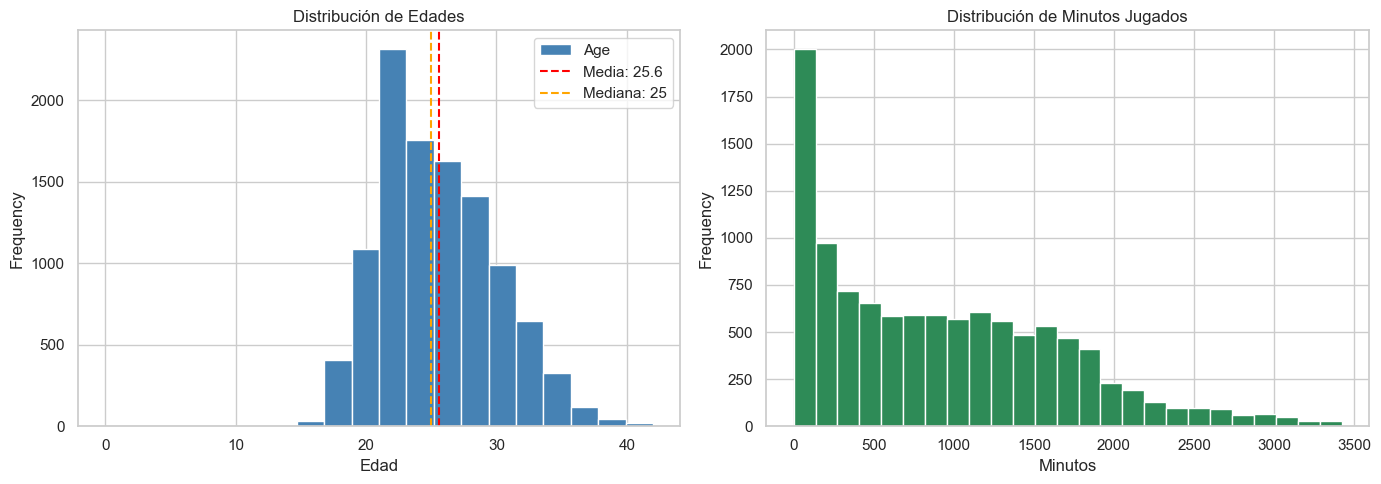

Asimetría en Edad: 0.27
Asimetría en Min: 0.727


In [ ]:
# ============================================================
# 7.2 DISTRIBUCIÓN DE EDADES Y MINUTOS JUGADOS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de edades
df_integrado['Age'].dropna().plot.hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(df_integrado['Age'].mean(), color='red', linestyle='--', label=f'Media: {df_integrado["Age"].mean():.1f}')
axes[0].axvline(df_integrado['Age'].median(), color='orange', linestyle='--', label=f'Mediana: {df_integrado["Age"].median():.0f}')
axes[0].set_title('Distribución de Edades')
axes[0].set_xlabel('Edad')
axes[0].legend()

# Histograma de minutos
df_integrado['Min'].dropna().plot.hist(bins=25, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Distribución de Minutos Jugados')
axes[1].set_xlabel('Minutos')

plt.tight_layout()
plt.show()
print('Asimetría en Edad:', round(df_integrado["Age"].skew(), 3))
print('Asimetría en Min:', round(df_integrado["Min"].skew(), 3))

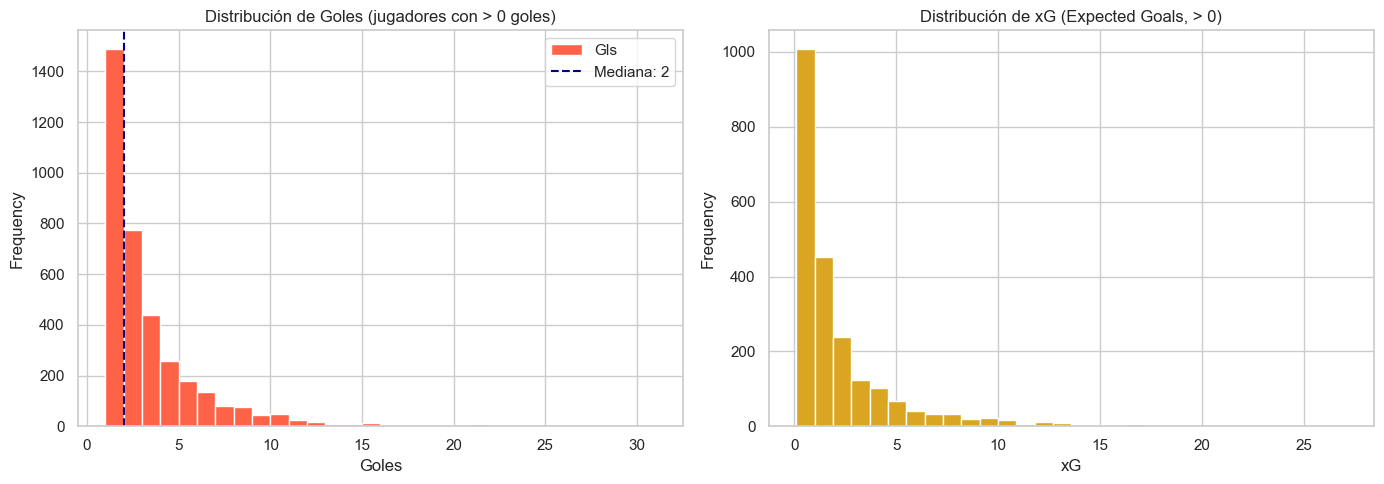

In [ ]:
# ============================================================
# 7.3 DISTRIBUCIÓN DE GOLES Y xG
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'Gls' in df_integrado.columns:
    goles_filtrado = df_integrado[df_integrado['Gls'] > 0]['Gls']  # solo jugadores con goles
    goles_filtrado.plot.hist(bins=30, ax=axes[0], color='tomato', edgecolor='white')
    axes[0].set_title('Distribución de Goles (jugadores con > 0 goles)')
    axes[0].set_xlabel('Goles')
    axes[0].axvline(goles_filtrado.median(), color='navy', linestyle='--',
                    label=f'Mediana: {goles_filtrado.median():.0f}')
    axes[0].legend()

if 'xG' in df_integrado.columns:
    xg_filtrado = df_integrado[df_integrado['xG'] > 0]['xG']
    xg_filtrado.plot.hist(bins=30, ax=axes[1], color='goldenrod', edgecolor='white')
    axes[1].set_title('Distribución de xG (Expected Goals, > 0)')
    axes[1].set_xlabel('xG')

plt.tight_layout()
plt.show()

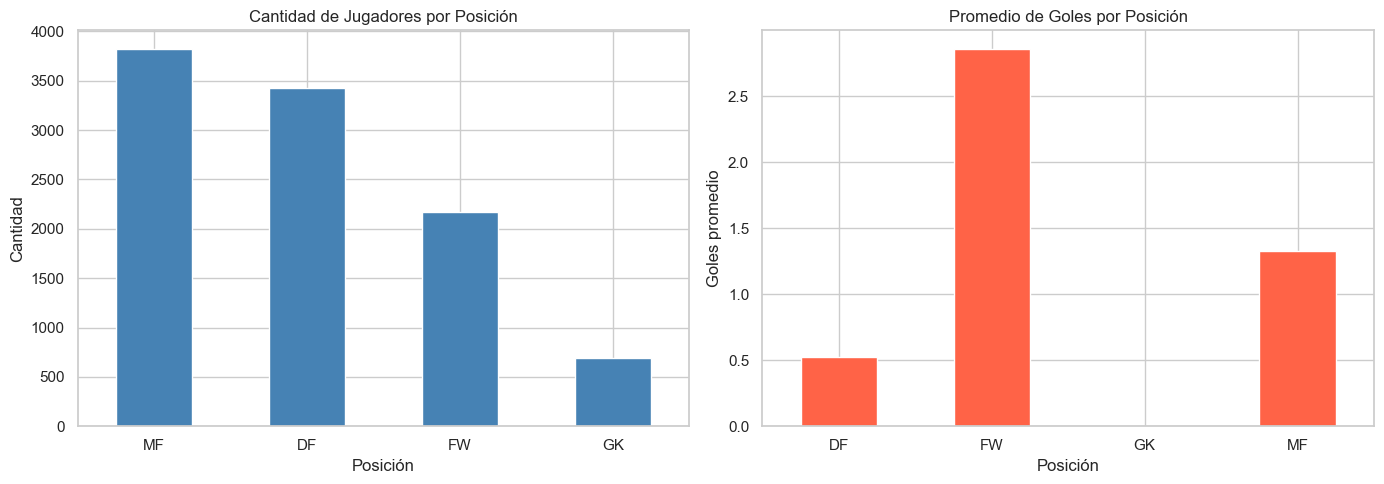

In [ ]:
# ============================================================
# 7.4 ANÁLISIS POR POSICIÓN
# ============================================================

posiciones_principales = ['GK', 'DF', 'MF', 'FW']
df_pos = df_integrado[df_integrado['Pos_principal'].isin(posiciones_principales)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo por posición
df_pos['Pos_principal'].value_counts().plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Cantidad de Jugadores por Posición')
axes[0].set_xlabel('Posición')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

# Goles promedio por posición (si existe la columna)
if 'Gls' in df_pos.columns:
    df_pos.groupby('Pos_principal')['Gls'].mean().plot.bar(ax=axes[1], color='tomato', edgecolor='white')
    axes[1].set_title('Promedio de Goles por Posición')
    axes[1].set_xlabel('Posición')
    axes[1].set_ylabel('Goles promedio')
    axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

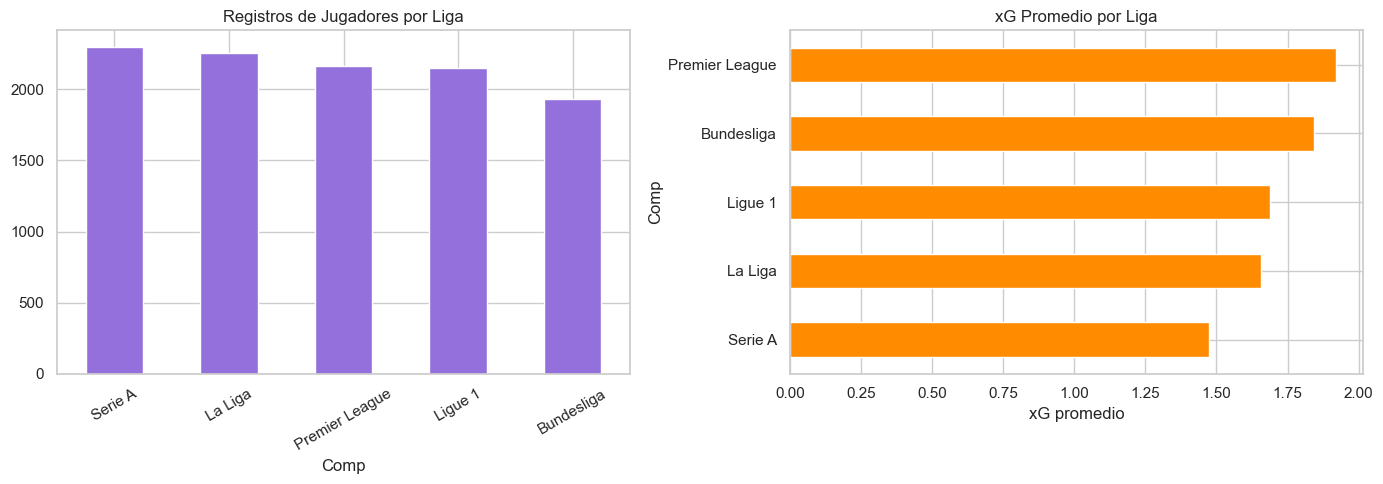

In [ ]:
# ============================================================
# 7.5 ANÁLISIS POR LIGA
# ============================================================

ligas_validas = ['Premier League', 'La Liga', 'Serie A', 'Bundesliga', 'Ligue 1']
df_liga = df_integrado[df_integrado['Comp'].isin(ligas_validas)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Jugadores por liga
df_liga['Comp'].value_counts().plot.bar(ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Registros de Jugadores por Liga')
axes[0].tick_params(axis='x', rotation=30)

# xG promedio por liga
if 'xG' in df_liga.columns:
    df_liga.groupby('Comp')['xG'].mean().sort_values().plot.barh(
        ax=axes[1], color='darkorange', edgecolor='white')
    axes[1].set_title('xG Promedio por Liga')
    axes[1].set_xlabel('xG promedio')

plt.tight_layout()
plt.show()

=== Evolución de Goles y xG por Temporada ===


Gls            xG       
            mean median   mean median
Temporada                            
2022-23      NaN    NaN    NaN    NaN
2023-24    1.116    0.0    NaN    NaN
2024-25    1.683    0.0  1.707    0.7
2025-26    1.116    0.0    NaN    NaN

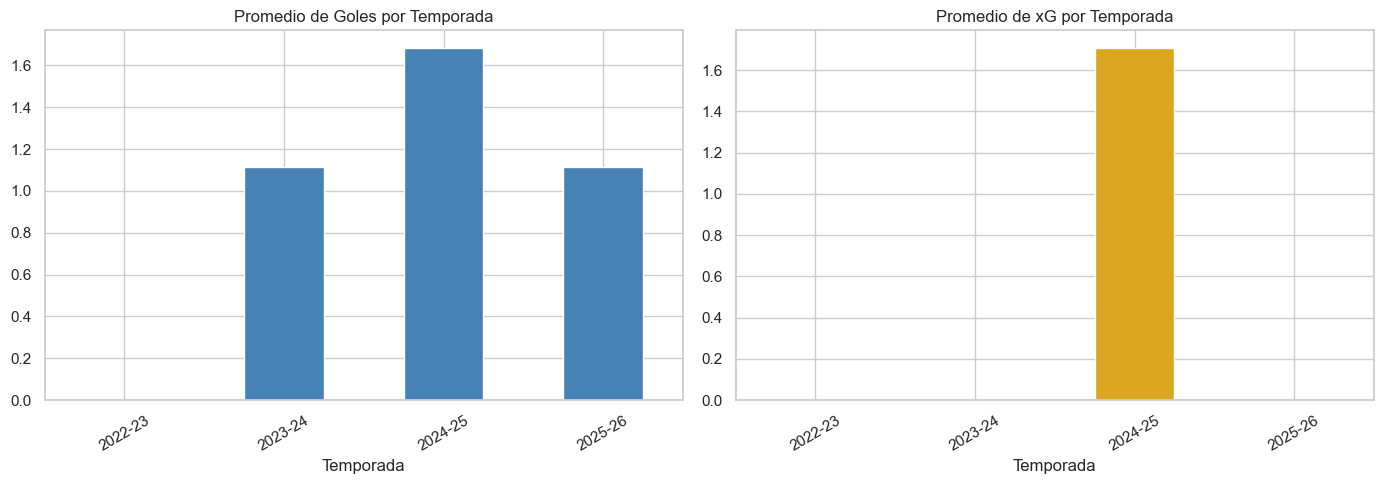

In [ ]:
# ============================================================
# 7.6 EVOLUCIÓN DEL RENDIMIENTO POR TEMPORADA
# ============================================================

if 'Gls' in df_integrado.columns:
    evolucion = df_integrado.groupby('Temporada')[['Gls', 'xG']].agg(['mean', 'median']).round(3)
    print('=== Evolución de Goles y xG por Temporada ===')
    display(evolucion)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    orden = ['2022-23', '2023-24', '2024-25', '2025-26']
    orden_disp = [t for t in orden if t in df_integrado['Temporada'].unique()]

    medias_gls = df_integrado.groupby('Temporada')['Gls'].mean().reindex(orden_disp)
    medias_xg  = df_integrado.groupby('Temporada')['xG'].mean().reindex(orden_disp)

    medias_gls.plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Promedio de Goles por Temporada')
    axes[0].tick_params(axis='x', rotation=30)

    medias_xg.plot.bar(ax=axes[1], color='goldenrod', edgecolor='white')
    axes[1].set_title('Promedio de xG por Temporada')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

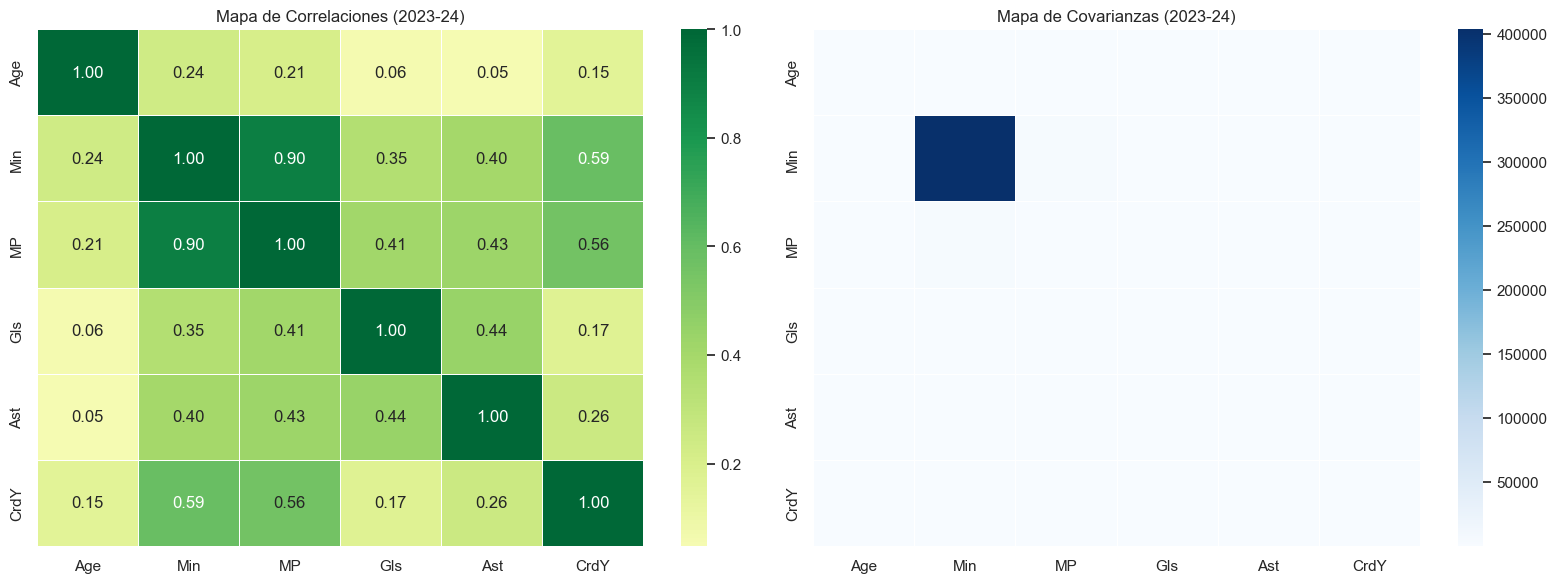


Correlación más alta con Gls:
Gls     1.000000
Ast     0.440256
MP      0.406956
Min     0.352410
CrdY    0.170098
Age     0.060653
Name: Gls, dtype: float64


In [ ]:
# ============================================================
# 7.7 CORRELACIONES (usando dataset top5 como referencia)
# ============================================================

cols_corr = [c for c in ['Age', 'Min', 'MP', 'Gls', 'Ast', 'xG', 'xAG', 'PrgC', 'PrgP', 'CrdY']
             if c in df_top5.columns]

corr_matrix = df_top5[cols_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title('Mapa de Correlaciones (2023-24)')

# Covarianza
cov_matrix = df_top5[cols_corr].cov()
sns.heatmap(cov_matrix, cmap='Blues', ax=axes[1], linewidths=0.5)
axes[1].set_title('Mapa de Covarianzas (2023-24)')

plt.tight_layout()
plt.show()

print('\nCorrelación más alta con Gls:')
if 'Gls' in corr_matrix.columns:
    print(corr_matrix['Gls'].sort_values(ascending=False).head(6))

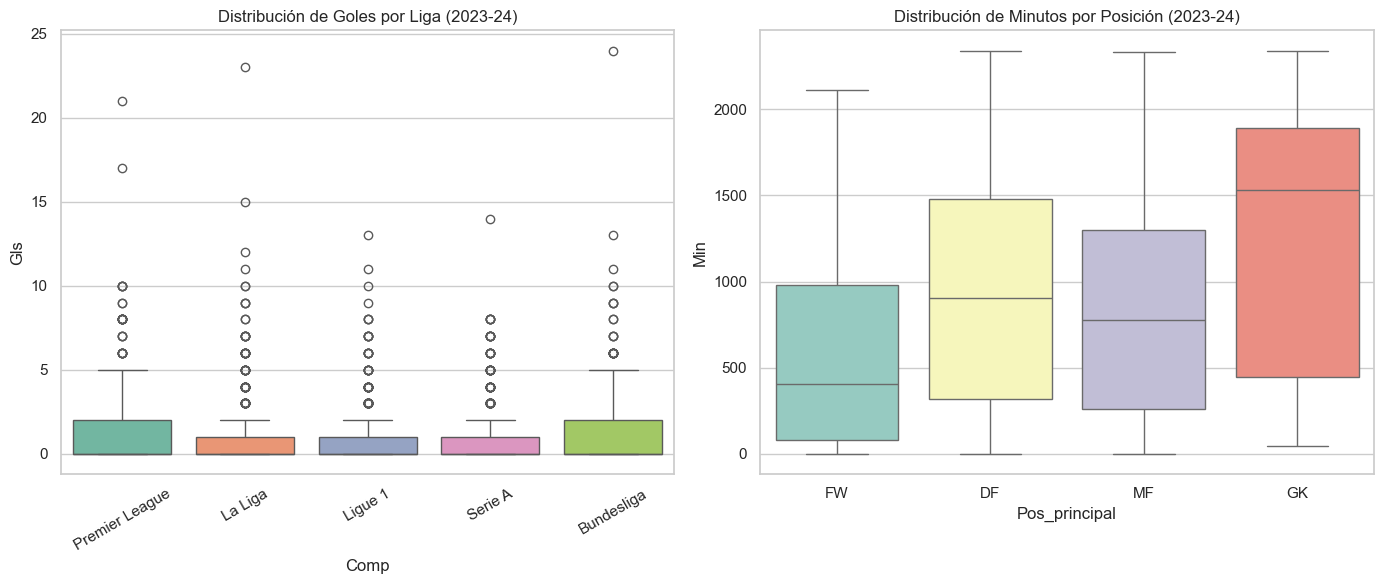

In [ ]:
# ============================================================
# 7.8 BOXPLOTS PARA ANÁLISIS DE DISPERSIÓN
# ============================================================

ligas_validas = ['Premier League', 'La Liga', 'Serie A', 'Bundesliga', 'Ligue 1']
df_box = df_top5[df_top5['Comp'].isin(ligas_validas)]

if 'Gls' in df_box.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.boxplot(data=df_box, x='Comp', y='Gls', ax=axes[0], palette='Set2')
    axes[0].set_title('Distribución de Goles por Liga (2023-24)')
    axes[0].tick_params(axis='x', rotation=30)

    pos_validas = [p for p in ['GK','DF','MF','FW'] if p in df_box['Pos_principal'].values]
    df_box_pos = df_box[df_box['Pos_principal'].isin(pos_validas)]
    sns.boxplot(data=df_box_pos, x='Pos_principal', y='Min', ax=axes[1], palette='Set3')
    axes[1].set_title('Distribución de Minutos por Posición (2023-24)')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# 7.9 SCATTER: Goles vs xG (validación de la métrica)
# ============================================================

if 'Gls' in df_top5.columns and 'xG' in df_top5.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for pos, color in [('FW', 'red'), ('MF', 'blue'), ('DF', 'green'), ('GK', 'gray')]:
        mask = df_top5['Pos_principal'] == pos
        ax.scatter(df_top5.loc[mask, 'xG'], df_top5.loc[mask, 'Gls'],
                   alpha=0.4, s=15, label=pos, color=color)
    
    # Línea de referencia: Gls = xG (rendimiento esperado)
    lim_max = min(df_top5['xG'].quantile(0.99), df_top5['Gls'].max())
    ax.plot([0, lim_max], [0, lim_max], 'k--', alpha=0.5, label='Gls = xG')
    
    ax.set_xlabel('Expected Goals (xG)')
    ax.set_ylabel('Goles Reales')
    ax.set_title('Goles Reales vs xG por Posición (2023-24)')
    ax.legend()
    ax.set_xlim(0, lim_max + 1)
    ax.set_ylim(0, df_top5['Gls'].quantile(0.99) + 2)
    plt.tight_layout()
    plt.show()
    
    # Correlación Pearson
    r = df_top5['Gls'].corr(df_top5['xG'])
    print(f'Correlación Pearson Gls vs xG: r = {r:.4f}')

---
## 8. Resultados del Preprocesamiento

### Resumen de transformaciones aplicadas:

| Problema | Columnas afectadas | Acción tomada |
|----------|-------------------|---------------|
| Formato inconsistente en `Nation` | Todos los datasets | Normalización a código ISO 3 letras |
| Formato inconsistente en `Comp` | Todos los datasets | Mapeo a nombre canónico |
| `Age` como float/string con días | 2024-25, 2025-26 | Extracción de parte entera |
| Nulos en columnas de rendimiento | Todos | Imputación con 0 (ausencia de actividad) |
| Nulos en columnas de portero | Todos (no-GK) | Mantenidos como NaN (estructural) |
| Posiciones combinadas (FW,MF) | Todos | Creación de `Pos_principal` |
| Variables categóricas | Pos, Comp | Label Encoding para ML |
| Escala de variables numéricas | Age, MP, Min, 90s | Z-score estandarización |
| Outliers (Gls, Age, xG) | Todos | Documentados, NO eliminados (válidos en contexto) |

In [ ]:
# ============================================================
# GUARDAR DATASET PROCESADO
# ============================================================

df_integrado.to_csv('dataset_futbol_procesado.csv', index=False, encoding='utf-8')
df_top5.to_csv('top5_2023_24_procesado.csv', index=False, encoding='utf-8')

print('✅ Datasets guardados:')
print(f'  → dataset_futbol_procesado.csv ({df_integrado.shape[0]:,} filas x {df_integrado.shape[1]} cols)')
print(f'  → top5_2023_24_procesado.csv ({df_top5.shape[0]:,} filas x {df_top5.shape[1]} cols)')

✅ Datasets guardados:
  → dataset_futbol_procesado.csv (10,793 filas x 34 cols)
  → top5_2023_24_procesado.csv (2,625 filas x 104 cols)


---
## 9. Paso 6 — Reflexión Técnica y Recomendaciones

### ¿Es posible establecer rangos de datos confiables?

Sí. Basados en el análisis descriptivo y el dominio del fútbol profesional, proponemos las siguientes reglas de calidad:

| Variable | Rango válido | Justificación |
|----------|-------------|---------------|
| `Age` | [15, 45] | Edad mínima realista en ligas profesionales |
| `MP` | [0, 38] | Máximo de jornadas en liga europea |
| `Min` | [0, 3420] | 38 partidos × 90 min |
| `Gls` | [0, 50] | Máximo histórico ~50 en una temporada |
| `xG` | [0, 50] | Coherente con cantidad de disparos |
| `Age` – `Born` | < 50 años de diferencia | Consistencia lógica |

### ¿Cuál fue el paso más demandante?
La **integración y reconciliación de esquemas** entre los cuatro datasets fue el paso más complejo. Cada temporada usa diferentes nombres de columnas, diferentes formatos de `Nation` y `Comp`, y diferente número de variables (de 37 hasta 267 columnas). Diseñar un pipeline que manejara estas inconsistencias de forma automática y reproducible requirió más iteración que cualquier otro paso.

### ¿Se automatizó alguna parte?
Sí. Se crearon funciones reutilizables:
- `normalizar_nation()` — estandariza el formato de nacionalidad
- `normalizar_edad()` — extrae año entero de diferentes formatos de edad
- `extraer_pos_principal()` — obtiene posición primaria
- `detectar_outliers_iqr()` — detección automática de atípicos
- `extraer_cols_disponibles()` — selección robusta de columnas

### ¿Qué tan escalable es el proceso?
Alta escalabilidad. Si se agrega una nueva temporada de FBref:
1. El pipeline de normalización de `Nation`, `Comp` y `Age` funciona sin cambios.
2. Solo habría que actualizar `mapa_ligas` si FBref cambia el prefijo de liga.
3. La integración por columnas comunes es automática.

### Recomendaciones para Aprendizaje Automático

1. **Clasificación de rendimiento:** Usar Gls, xG, Ast, PrgC como features para clasificar jugadores en categorías de rendimiento (alto/medio/bajo). Algoritmos recomendados: Random Forest, Gradient Boosting.

2. **Predicción de goles:** Regresión con xG, SoT, Min, Pos_encoded como predictores. Alta correlación xG-Gols (r ≈ 0.9) favorece modelos lineales.

3. **Clustering de perfiles:** Usar K-Means o DBSCAN sobre variables estandarizadas para identificar arquetipos de jugadores. Excluir porteros o tratarlos separadamente.

4. **Consideraciones importantes:**
   - Filtrar por mínimo de minutos (ej. `Min >= 450`) para evitar sesgo por jugadores con muy poca participación.
   - Separar porteros del resto para modelos de campo.
   - Tener en cuenta el desbalance de clases si se clasifica por posición.
   - Para modelos temporales, usar la temporada como variable de control o entrenar por temporada.

---
## 10. Conclusiones

- Se procesaron exitosamente **11,020 registros** de cuatro fuentes de datos sobre estadísticas de jugadores de fútbol en las Top 5 ligas europeas (2022-2026).

- Se identificaron y resolvieron inconsistencias sistemáticas en los formatos de `Nation`, `Comp` y `Age` entre temporadas mediante funciones automatizadas y reproducibles.

- Los nulos en columnas de portero son **estructurales** (no aplican para jugadores de campo) y fueron correctamente manejados de forma diferenciada a los nulos en estadísticas de rendimiento.

- El análisis descriptivo reveló que: (a) la edad promedio es ~25 años, (b) la distribución de goles y xG es fuertemente asimétrica a la derecha, (c) la correlación entre goles reales y xG es muy alta (~0.9), validando la calidad del dato.

- El esquema estrella propuesto permite almacenar y consultar los datos eficientemente para análisis OLAP y modelos de aprendizaje automático.

- El dataset resultante está listo para aplicar técnicas de ML supervisado (predicción de goles, clasificación de rendimiento) y no supervisado (clustering de perfiles tácticos).

---
## 11. Referencias

- Sports Reference LLC. FBref.com. Recuperado de https://fbref.com
- Kaggle. Football Player Stats 2022-23. Recuperado de https://www.kaggle.com
- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.
- FBref Glossary: https://fbref.com/en/fb/glossary

---
## Anexos

- `dataset_futbol_procesado.csv` — Dataset integrado y preprocesado (11,020 registros)
- `top5_2023_24_procesado.csv` — Dataset 2023-24 limpio para análisis específico
- Este notebook `.ipynb` contiene todo el código fuente del proceso